## Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from wordcloud import WordCloud

import os
import time
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from transformers import BertTokenizer, BertModel, BertConfig
from torch.utils.data import DataLoader, Dataset

2025-05-03 09:59:21.519743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746266361.704209      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746266361.760112      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_path =  '/kaggle/input/liar-fake-news-dataset/train.tsv' #'/content/drive/MyDrive/KP/train.tsv'
valid_path =  '/kaggle/input/liar-fake-news-dataset/valid.tsv' #'/content/drive/MyDrive/KP/valid.tsv'
test_path = '/kaggle/input/liar-fake-news-dataset/test.tsv' #/content/drive/MyDrive/KP/test.tsv'

print(torch.__version__)

2.5.1+cu124


## EDA

In [3]:
train = pd.read_csv(train_path, sep='\t', header=None)
test = pd.read_csv(test_path, sep='\t', header=None)
valid = pd.read_csv(valid_path, sep='\t', header=None)

In [4]:
train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10235,5473.json,mostly-true,There are a larger number of shark attacks in ...,"animals,elections",aclu-florida,NaN,Florida,none,0.0,1.0,1.0,1.0,0.0,"interview on ""The Colbert Report"""
10236,3408.json,mostly-true,Democrats have now become the party of the [At...,elections,alan-powell,NaN,Georgia,republican,0.0,0.0,0.0,1.0,0.0,an interview
10237,3959.json,half-true,Says an alternative to Social Security that op...,"retirement,social-security",herman-cain,NaN,Georgia,republican,4.0,11.0,5.0,3.0,3.0,a Republican presidential debate
10238,2253.json,false,On lifting the U.S. Cuban embargo and allowing...,"florida,foreign-policy",jeff-greene,NaN,Florida,democrat,3.0,1.0,3.0,0.0,0.0,a televised debate on Miami's WPLG-10 against ...


In [5]:
train = train.drop_duplicates()
train = train.dropna().reset_index(drop=True)
print(train.shape)

valid = valid.drop_duplicates()
valid = valid.dropna().reset_index(drop=True)
print(valid.shape)

test = test.drop_duplicates()
test = test.dropna().reset_index(drop=True)
print(test.shape)

(6721, 14)
(861, 14)
(853, 14)


In [6]:
train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece
4,153.json,half-true,I'm the only person on this stage who has work...,ethics,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a Democratic debate in Philadelphia, Pa."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6716,13344.json,pants-fire,"Recently though, the media has reported on tho...",elections,john-rafferty,State Senator,Pennsylvania,republican,0.0,0.0,0.0,0.0,1.0,a debate.
6717,13239.json,barely-true,Stopped by Smiley Cookie to pick up some great...,food,donald-trump,President-Elect,New York,republican,63.0,114.0,51.0,37.0,61.0,a Facebook post.
6718,11018.json,barely-true,The Supreme Courts views are radically out of ...,"gays-and-lesbians,polls,supreme-court",ted-cruz,Senator,Texas,republican,36.0,33.0,15.0,19.0,8.0,an interview on NPR
6719,2930.json,half-true,"When it comes to the state deficit, Wisconsin ...",state-budget,alberta-darling,"State Senator, 8th District",Wisconsin,republican,1.0,1.0,2.0,1.0,1.0,a television interview


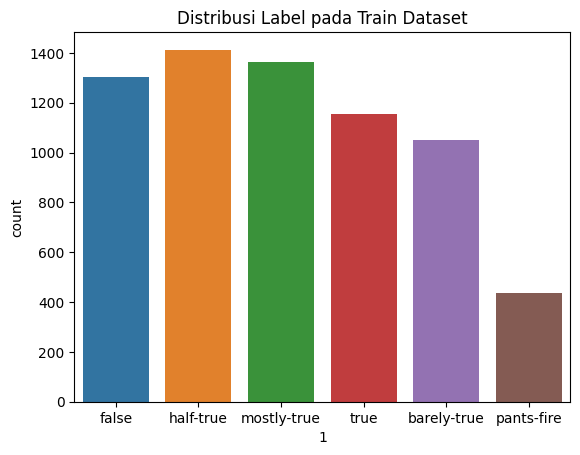

In [7]:
sns.countplot(x=train[1])
plt.title("Distribusi Label pada Train Dataset")
plt.show()

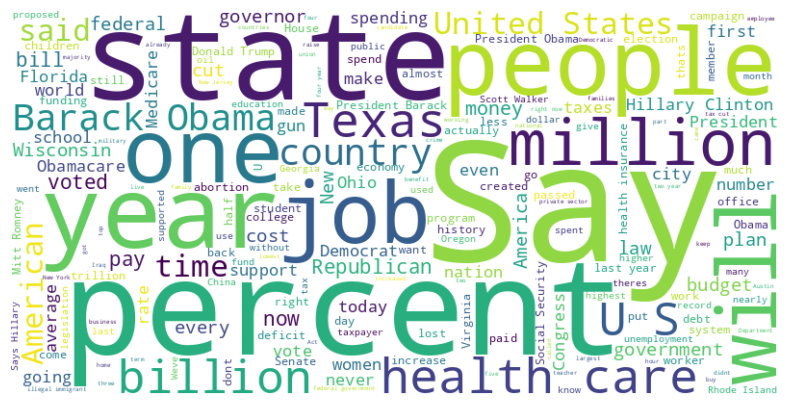

In [8]:
trainWC = ' '.join(train[2])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(trainWC)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


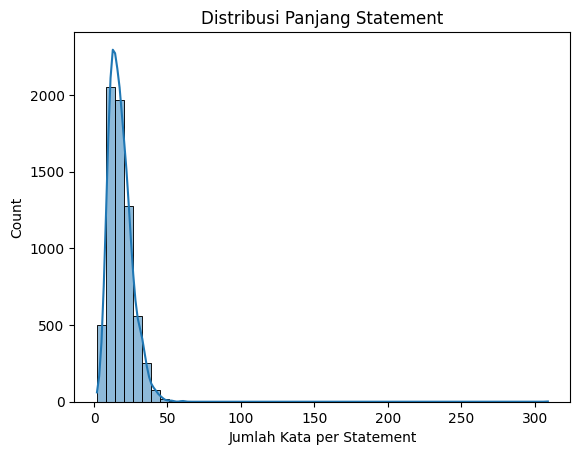

In [9]:
count_word = train[2].apply(lambda x: len(str(x).split()))
sns.histplot(count_word, bins=50, kde=True)
plt.title("Distribusi Panjang Statement")
plt.xlabel("Jumlah Kata per Statement")
plt.show()

## Preprocessing

In [10]:
def preprocessing(dataset, num_labels):
  if num_labels == 2:
    dataset['labels']=[1 if x=="true"or x=="mostly-true" else 0 for x in dataset[1]]

  elif num_labels == 6:
    cond = [(dataset[1]=="true"), (dataset[1]=="mostly-true"), (dataset[1]=="half-true"), (dataset[1]=="false"), (dataset[1]=="barely-true"), (dataset[1]=="pants-fire")]
    choice = [0,1,2,3,4,5]
    dataset['labels']= np.select(cond, choice, default=0)

  dataset = dataset.drop(labels=[0,1,8,9,10,11,12] ,axis=1).reset_index(drop=True)

  metadata = []
  for i in range(len(dataset)):
    metadata.append(' '.join(dataset.loc[i, data] if dataset.loc[i, data] != 0 else 'None' for data in [3,4,5,6,7,13]))


  dataset[14] = metadata
  dataset['meta'] = dataset[14].astype('str')
  dataset['sentence'] = dataset[2]
  dataset = dataset.drop([2,3,4,5,6,7,13,14], axis=1)

  return dataset


In [11]:
train[1].value_counts()

1
half-true      1413
mostly-true    1362
false          1304
true           1154
barely-true    1052
pants-fire      436
Name: count, dtype: int64

In [12]:
train = train.groupby(1).apply(lambda x: x.sample(frac=0.4, replace=True)).reset_index(drop=True)
valid = valid.groupby(1).apply(lambda x: x.sample(frac=0.5, replace=True)).reset_index(drop=True)
test = test.groupby(1).apply(lambda x: x.sample(frac=0.5, replace=True)).reset_index(drop=True)

/tmp/ipykernel_19/375606082.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = train.groupby(1).apply(lambda x: x.sample(frac=0.4, replace=True)).reset_index(drop=True)
/tmp/ipykernel_19/375606082.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  valid = valid.groupby(1).apply(lambda x: x.sample(frac=0.5, replace=True)).reset_index(drop=True)
/tmp/ipykernel_19/375606082.py:3: DeprecationWarning: 

In [13]:
train

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,5065.json,barely-true,Says Milwaukee County buses are no less safe n...,"crime,transportation",chris-abele,Philanthropist,Wisconsin,none,3.0,5.0,4.0,4.0,2.0,a television interview
1,739.json,barely-true,I introduced a bill that wouldve helped stop t...,economy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,"a speech in Dunedin, Fla."
2,9990.json,barely-true,We have a goal of 10 percent of [City of Provi...,"city-government,debates,jobs,women",jorge-elorza,Law professor,Rhode Island,democrat,1.0,1.0,0.0,2.0,0.0,a radio debate
3,4665.json,barely-true,We cut property taxes by one-third in the stat...,"new-hampshire-2012,taxes",rick-perry,Governor,Texas,republican,30.0,30.0,42.0,23.0,18.0,"a forum in Hampton, N.H."
4,13250.json,barely-true,"Says Syrian refugees are not being vetted, and...","debates,foreign-policy,immigration,public-safe...",pat-mccrory,Governor of North Carolina,North Carolina,republican,5.0,2.0,3.0,0.0,1.0,a North Carolina governor's race debate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2684,7741.json,true,If you are a federally licensed gun dealer and...,guns,david-cicilline,mayor of Providence,Rhode Island,democrat,7.0,4.0,5.0,4.0,1.0,an appearance on 10 News Conference
2685,7700.json,true,Says more Austinites voted in the citys 1973 e...,"elections,history",bee-moorhead,"Executive director, Texas IMPACT",Texas,democrat,0.0,0.0,0.0,1.0,0.0,a civic summit.
2686,3734.json,true,The Obama administration increased the deporta...,immigration,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,a speech in El Paso
2687,4166.json,true,Says that U.S. Rep. Allen West is a constituen...,"elections,redistricting",debbie-wasserman-schultz,"U.S. Representative, Florida District 23",Florida,democrat,7.0,9.0,8.0,15.0,3.0,an interview on CNN


In [14]:
Trains = preprocessing(train, 2)

In [15]:
Trains

,labels,meta,sentence
0,0,"crime,transportation chris-abele Philanthropis...",Says Milwaukee County buses are no less safe n...
1,0,economy barack-obama President Illinois democr...,I introduced a bill that wouldve helped stop t...
2,0,"city-government,debates,jobs,women jorge-elorz...",We have a goal of 10 percent of [City of Provi...
3,0,"new-hampshire-2012,taxes rick-perry Governor T...",We cut property taxes by one-third in the stat...
4,0,"debates,foreign-policy,immigration,public-safe...","Says Syrian refugees are not being vetted, and..."
...,...,...,...
2684,1,guns david-cicilline mayor of Providence Rhode...,If you are a federally licensed gun dealer and...
2685,1,"elections,history bee-moorhead Executive direc...",Says more Austinites voted in the citys 1973 e...
2686,1,immigration barack-obama President Illinois de...,The Obama administration increased the deporta...
2687,1,"elections,redistricting debbie-wasserman-schul...",Says that U.S. Rep. Allen West is a constituen...


In [16]:
Trains['labels'].value_counts()

labels
0    1682
1    1007
Name: count, dtype: int64

In [17]:
Trains = preprocessing(train, 6)

In [18]:
Trains

,labels,meta,sentence
0,4,"crime,transportation chris-abele Philanthropis...",Says Milwaukee County buses are no less safe n...
1,4,economy barack-obama President Illinois democr...,I introduced a bill that wouldve helped stop t...
2,4,"city-government,debates,jobs,women jorge-elorz...",We have a goal of 10 percent of [City of Provi...
3,4,"new-hampshire-2012,taxes rick-perry Governor T...",We cut property taxes by one-third in the stat...
4,4,"debates,foreign-policy,immigration,public-safe...","Says Syrian refugees are not being vetted, and..."
...,...,...,...
2684,0,guns david-cicilline mayor of Providence Rhode...,If you are a federally licensed gun dealer and...
2685,0,"elections,history bee-moorhead Executive direc...",Says more Austinites voted in the citys 1973 e...
2686,0,immigration barack-obama President Illinois de...,The Obama administration increased the deporta...
2687,0,"elections,redistricting debbie-wasserman-schul...",Says that U.S. Rep. Allen West is a constituen...


In [19]:
Trains['labels'].value_counts()

labels
2    565
1    545
3    522
0    462
4    421
5    174
Name: count, dtype: int64

## Model

In [20]:
class BiLSTM(nn.Module):
  def __init__(self, hidden_dim, embedding_dim, label_size):
    super(BiLSTM, self).__init__()
    self.hidden_dim = hidden_dim
    self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=2, bidirectional=True)
    self.classifier = nn.Linear(hidden_dim*2, label_size)

  def forward(self, bert_embedding):
    lstm_out, _ = self.lstm(bert_embedding)
    logits = self.classifier(lstm_out)
    return logits

In [21]:
class Bert_BiLSTM(nn.Module):
  def __init__(self, num_layer, num_labels):
    super().__init__()
    self.num_labels = num_labels
    self.num_layer = num_layer
    self.bert = BertModel.from_pretrained('bert-base-uncased', low_cpu_mem_usage=False, device_map=None)
    self.layerNorm = nn.LayerNorm(self.bert.config.hidden_size, eps=1e-12)
    self.dropout = nn.Dropout(self.bert.config.hidden_dropout_prob)
    self.classifier = BiLSTM(hidden_dim=self.bert.config.hidden_size*2, embedding_dim=self.bert.config.hidden_size*2, label_size=self.num_labels)

    nn.init.xavier_normal_(self.classifier.classifier.weight)

    for name, param in self.classifier.lstm.named_parameters():
      if 'weight' in name:
        nn.init.xavier_normal_(param)

    self.set_encoder()

  def forward(self, metaID, metaMask, stateID, stateMask):
    metadata = self.bert(metaID.squeeze(1), metaMask.squeeze(1))
    metaNorm = self.dropout(self.layerNorm(metadata.last_hidden_state[:, 0, :]))

    sentence = self.bert(stateID.squeeze(1), stateMask.squeeze(1))
    sentenceNorm = self.dropout(self.layerNorm(sentence.last_hidden_state[:, 0, :]))

    output = torch.cat((metaNorm, sentenceNorm), dim=-1)
    logits = self.classifier(output)
    return logits

  def set_encoder(self):
    for param in self.bert.parameters():
      param.requires_grad = True

    for i in range(0, self.num_layer):
      for param in self.bert.encoder.layer[i].parameters():
        param.requires_grad = False

## Tokenization

In [22]:
class text_dataset(Dataset):
  def __init__(self, dataset):
    self.statement = dataset['sentence']
    self.meta = dataset['meta']
    self.labels = dataset['labels']
    self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

  def __getitem__(self, idx):
    state_encoding = self.tokenizer.encode_plus(
        str(self.statement[idx]),
        add_special_tokens = True,
        max_length = 512,
        padding = 'max_length',
        return_attention_mask = True,
        truncation = True,
        return_tensors = 'pt'
    )

    meta_encoding = self.tokenizer.encode_plus(
        str(self.meta[idx]),
        add_special_tokens = True,
        max_length = 512,
        padding = 'max_length',
        return_attention_mask = True,
        truncation = True,
        return_tensors = 'pt'
    )

    return {
        'meta': {
            'input_ids' : meta_encoding['input_ids'],
            'attention_mask' : meta_encoding['attention_mask']
        },
        'state': {
            'input_ids' : state_encoding['input_ids'],
            'attention_mask' : state_encoding['attention_mask']
        },
        'labels' : self.labels[idx]
    }

  def __len__(self):
    return len(self.statement)

Train2 = preprocessing(train, num_labels=2)
Valid2 = preprocessing(valid, num_labels=2)
Test2 = preprocessing(test, num_labels=2)

Train6 = preprocessing(train, num_labels=6)
Valid6 = preprocessing(valid, num_labels=6)
Test6 = preprocessing(test, num_labels=6)

dataloaders_dict = {
  'train': {
      '2': DataLoader(text_dataset(Train2), batch_size=16, shuffle=True),
      '6': DataLoader(text_dataset(Train6), batch_size=16, shuffle=True)
  },
  'val': {
      '2': DataLoader(text_dataset(Valid2), batch_size=16, shuffle=True),
      '6': DataLoader(text_dataset(Valid6), batch_size=16, shuffle=True)
  },

  'test': {
      '2': DataLoader(text_dataset(Test2), batch_size=16, shuffle=True),
      '6': DataLoader(text_dataset(Test6), batch_size=16, shuffle=True)
  }
}

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## Training

In [23]:
from torch.cuda.amp import autocast, GradScaler

def train_model(num_layer, bert_lr, num_labels):
  torch.cuda.empty_cache()
    
  model = Bert_BiLSTM(num_layer, num_labels=num_labels)

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  num_epoch = [3,4,5,6]    

  scaler = GradScaler()

  optimizer = optim.AdamW(
    [
        {"params":model.bert.parameters(),"lr": bert_lr},
        {"params": model.layerNorm.parameters(), "lr": 0.001},
        {"params":model.classifier.parameters(), "lr": 0.001}
  ])

  criterion=nn.CrossEntropyLoss()
  best_model = None
  best_acc = 0

  time_start = time.time()  
  for epoch in range(max(num_epoch)):
    val_loss = 0.0
    val_correct = 0  # Variable to track correct predictions  
    val_total = 0  # Variable to track total samples
    print('-' * 10) 
    for phase in ['train', 'val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()

      for batch in dataloaders_dict[phase][str(num_labels)]:
        meta = batch['meta']
        state = batch['state']

        metaID = meta['input_ids'].to(device)
        metaMask = meta['attention_mask'].to(device)
        stateID = state['input_ids'].to(device)
        stateMask = state['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          with autocast(): 
            outputs = model(metaID, metaMask, stateID, stateMask)
            loss = criterion(outputs, labels)

          if phase == 'train':
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
          if phase == 'val':
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)  
            val_correct += (predicted == labels).sum().item()  

        del metaID, metaMask, stateID, stateMask, labels
        torch.cuda.empty_cache()
      
    val_acc = val_correct / val_total
    total_val_loss = val_loss / len(dataloaders_dict['val'][str(num_labels)])
    
    print(f'Epoch {epoch+1}/{max(num_epoch)} | Validation Loss: {total_val_loss:.4f} | Validation Acc: {val_acc:.4f}')
    
    if epoch+1 in num_epoch:
      elapse = time.time() - time_start
      print("====================================================================================================")
      print('Training complete in {:.0f}m {:.0f}s'.format(elapse // 60, elapse % 60))
      print(f"Frozen BERT Layers: 0 to {num_layer-1}")
      print(f"Epoch: {epoch+1}")
      print(f"Learning Rate: {bert_lr}")
      acc = evaluate(model, num_labels=num_labels)
      print("====================================================================================================")
      
      if acc > best_acc:
        best_acc = acc
        best_model = copy.deepcopy(model)

  best_model = best_model.to('cpu')
  del model, optimizer, criterion
  torch.cuda.empty_cache()

  return best_model, best_acc

## Result

In [24]:
def evaluate(model, num_labels):
  model.eval()
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  predsList = []
  labelsList = []

  with torch.no_grad():
    for batch in dataloaders_dict['test'][str(num_labels)]:
      meta = batch['meta']
      state = batch['state']

      TmetaID = meta['input_ids'].to(device)
      TmetaMask = meta['attention_mask'].to(device)
      TstateID = state['input_ids'].to(device)
      TstateMask = state['attention_mask'].to(device)
      Tlabels = batch['labels'].to(device)

      with autocast():
        outputs = model(TmetaID, TmetaMask, TstateID, TstateMask)
      preds = torch.argmax(outputs, dim=1)

      predsList.extend(preds.cpu().numpy())
      labelsList.extend(Tlabels.cpu().numpy())

      del TmetaID, TmetaMask, TstateID, TstateMask, Tlabels
      torch.cuda.empty_cache()

  print("Classification Report:\n")
  print(classification_report(labelsList, predsList, zero_division=0))

  cm = confusion_matrix(labelsList, predsList)
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

  acc = accuracy_score(labelsList, predsList)
  precision = precision_score(labelsList, predsList, average='weighted', zero_division=0)
  recall = recall_score(labelsList, predsList, average='weighted', zero_division=0)
  f1 = f1_score(labelsList, predsList, average='weighted', zero_division=0)

  print(f"Accuracy : {acc:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall   : {recall:.4f}")
  print(f"F1-Score : {f1:.4f}")

  return acc


In [25]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def Result(num_labels):
  best_model = None
  best_acc = 0

  num_layers = [2,4,6]
  bert_lr = [2e-5, 3e-5]

  for layer in num_layers:
    for lr in bert_lr:
      model, acc = train_model(layer, lr, num_labels)

      if acc > best_acc:
        best_acc = acc
        best_model = copy.deepcopy(model)

      del model
      torch.cuda.empty_cache()
      print("====================================================================================================")

  torch.save(best_model.state_dict(), f'best_model_{num_labels}.pth')


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6453 | Validation Acc: 0.6566
----------
Epoch 2/6 | Validation Loss: 0.6631 | Validation Acc: 0.6056
----------
Epoch 3/6 | Validation Loss: 0.6739 | Validation Acc: 0.6357
Training complete in 8m 9s
Frozen BERT Layers: 0 to 1
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.72      0.70       267
           1       0.49      0.44      0.46       160

    accuracy                           0.62       427
   macro avg       0.58      0.58      0.58       427
weighted avg       0.61      0.62      0.61       427



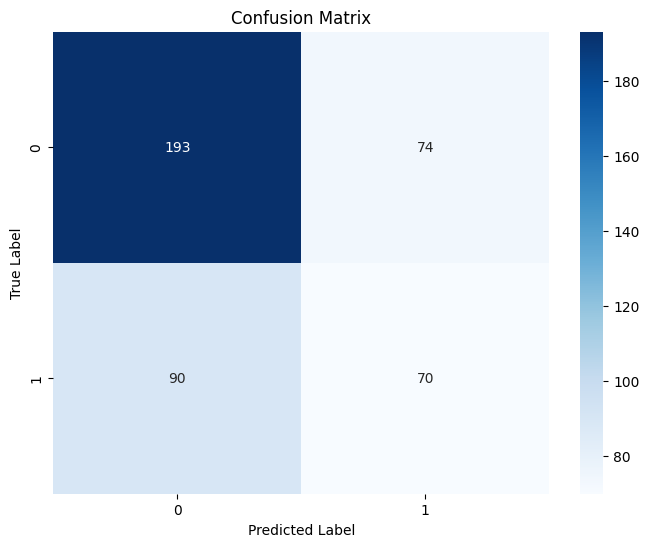

Accuracy : 0.6159
Precision: 0.6086
Recall   : 0.6159
F1-Score : 0.6114
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.7976 | Validation Acc: 0.6311
Training complete in 11m 2s
Frozen BERT Layers: 0 to 1
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.60      0.66       267
           1       0.48      0.62      0.54       160

    accuracy                           0.61       427
   macro avg       0.60      0.61      0.60       427
weighted avg       0.63      0.61      0.61       427



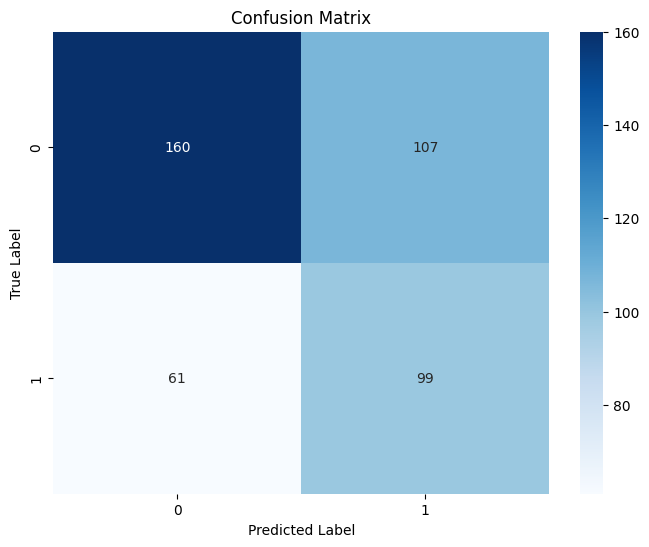

Accuracy : 0.6066
Precision: 0.6328
Recall   : 0.6066
F1-Score : 0.6127
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 0.9994 | Validation Acc: 0.6311
Training complete in 13m 55s
Frozen BERT Layers: 0 to 1
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       267
           1       0.56      0.51      0.53       160

    accuracy                           0.67       427
   macro avg       0.64      0.63      0.64       427
weighted avg       0.66      0.67      0.66       427



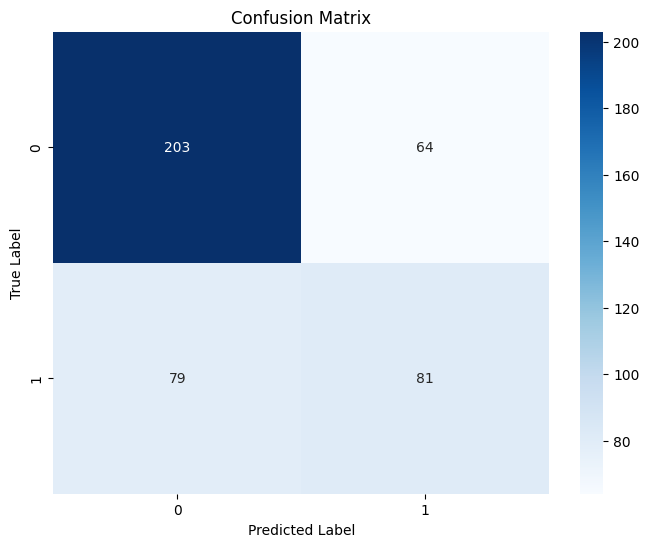

Accuracy : 0.6651
Precision: 0.6594
Recall   : 0.6651
F1-Score : 0.6614
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.2201 | Validation Acc: 0.6195
Training complete in 16m 45s
Frozen BERT Layers: 0 to 1
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.65      0.68       267
           1       0.49      0.57      0.53       160

    accuracy                           0.62       427
   macro avg       0.61      0.61      0.61       427
weighted avg       0.63      0.62      0.62       427



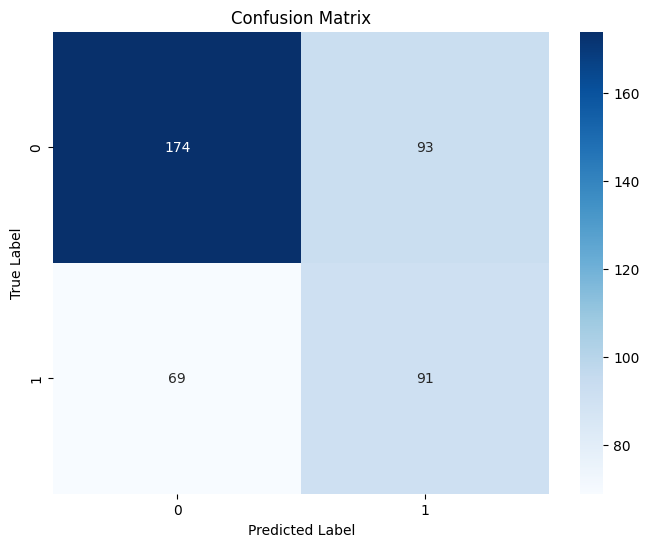

Accuracy : 0.6206
Precision: 0.6331
Recall   : 0.6206
F1-Score : 0.6249


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6481 | Validation Acc: 0.6566
----------
Epoch 2/6 | Validation Loss: 0.6524 | Validation Acc: 0.6566
----------
Epoch 3/6 | Validation Loss: 0.6417 | Validation Acc: 0.6566
Training complete in 8m 9s
Frozen BERT Layers: 0 to 1
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       267
           1       0.00      0.00      0.00       160

    accuracy                           0.63       427
   macro avg       0.31      0.50      0.38       427
weighted avg       0.39      0.63      0.48       427



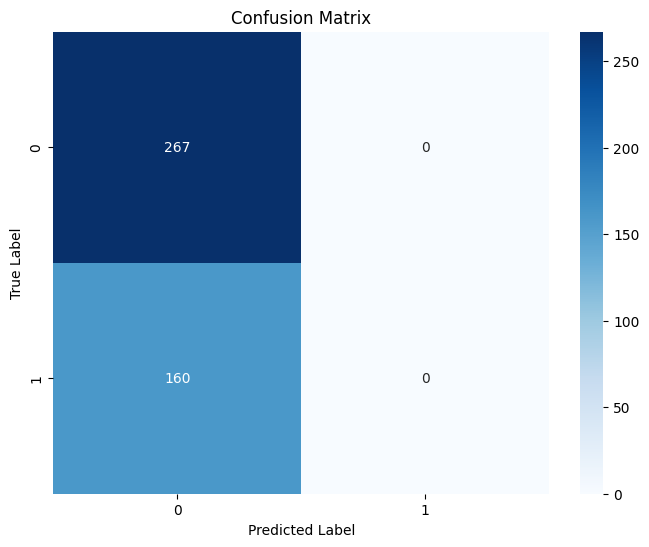

Accuracy : 0.6253
Precision: 0.3910
Recall   : 0.6253
F1-Score : 0.4811
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.6439 | Validation Acc: 0.6566
Training complete in 11m 3s
Frozen BERT Layers: 0 to 1
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       267
           1       0.00      0.00      0.00       160

    accuracy                           0.63       427
   macro avg       0.31      0.50      0.38       427
weighted avg       0.39      0.63      0.48       427



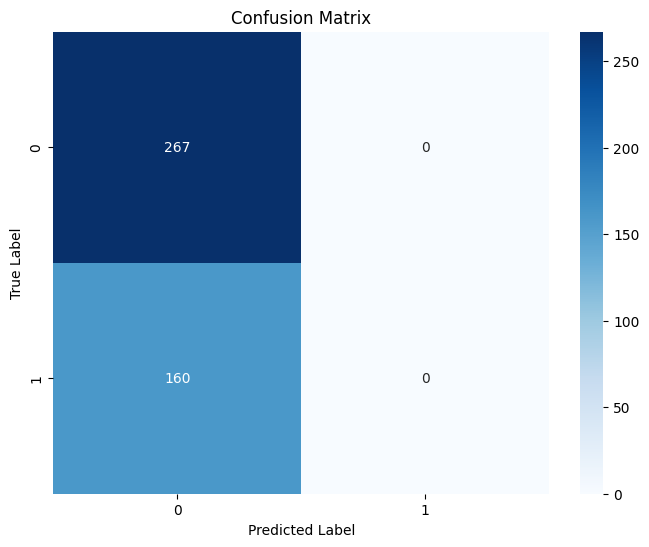

Accuracy : 0.6253
Precision: 0.3910
Recall   : 0.6253
F1-Score : 0.4811
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 0.6639 | Validation Acc: 0.6566
Training complete in 13m 56s
Frozen BERT Layers: 0 to 1
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.96      0.76       267
           1       0.47      0.06      0.10       160

    accuracy                           0.62       427
   macro avg       0.55      0.51      0.43       427
weighted avg       0.57      0.62      0.51       427



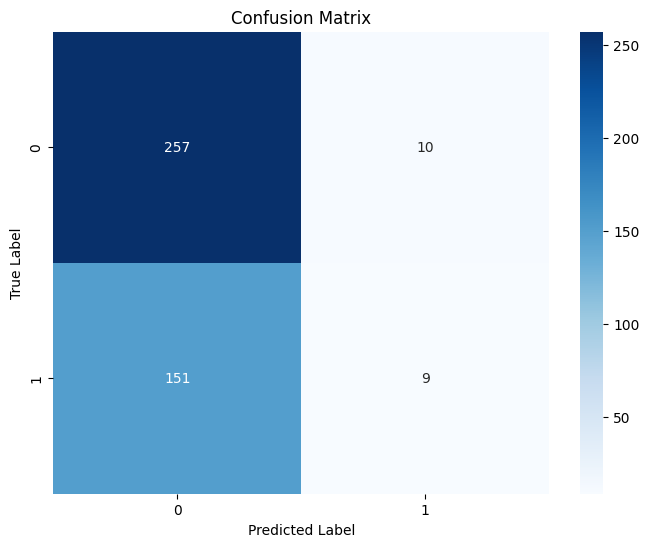

Accuracy : 0.6230
Precision: 0.5714
Recall   : 0.6230
F1-Score : 0.5138
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 0.6445 | Validation Acc: 0.6566
Training complete in 16m 49s
Frozen BERT Layers: 0 to 1
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       267
           1       0.00      0.00      0.00       160

    accuracy                           0.63       427
   macro avg       0.31      0.50      0.38       427
weighted avg       0.39      0.63      0.48       427



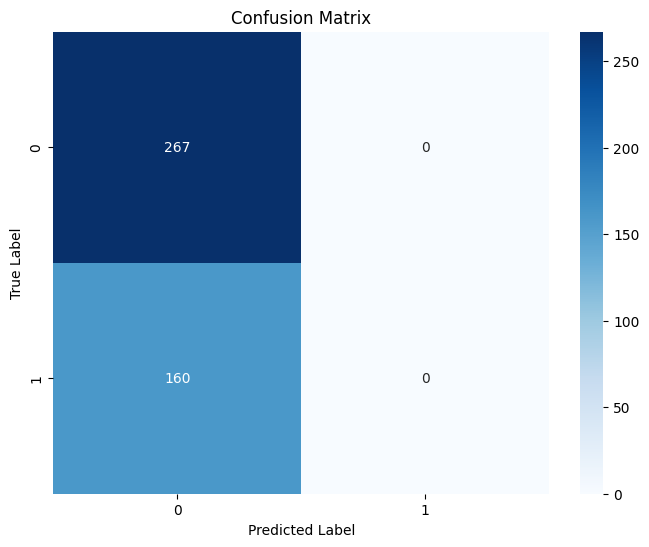

Accuracy : 0.6253
Precision: 0.3910
Recall   : 0.6253
F1-Score : 0.4811


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6394 | Validation Acc: 0.6520
----------
Epoch 2/6 | Validation Loss: 0.8784 | Validation Acc: 0.6566
----------
Epoch 3/6 | Validation Loss: 0.7210 | Validation Acc: 0.6613
Training complete in 7m 43s
Frozen BERT Layers: 0 to 3
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.78      0.74       267
           1       0.55      0.44      0.49       160

    accuracy                           0.66       427
   macro avg       0.63      0.61      0.62       427
weighted avg       0.64      0.66      0.65       427



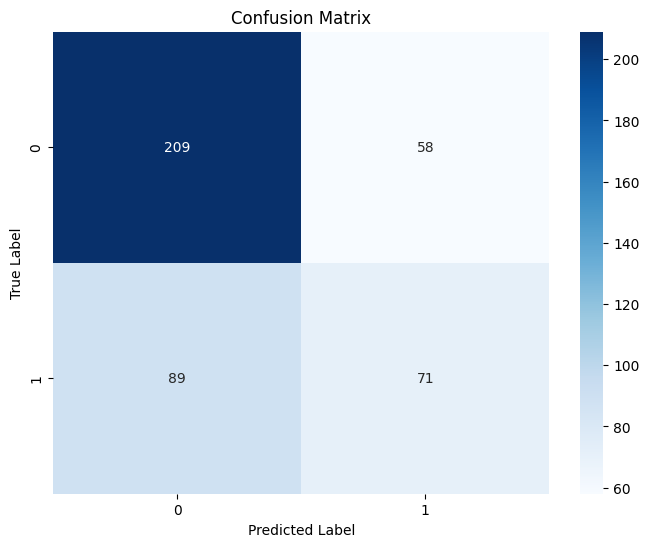

Accuracy : 0.6557
Precision: 0.6448
Recall   : 0.6557
F1-Score : 0.6467
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.8411 | Validation Acc: 0.6752
Training complete in 10m 27s
Frozen BERT Layers: 0 to 3
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.77      0.74       267
           1       0.54      0.46      0.50       160

    accuracy                           0.65       427
   macro avg       0.62      0.61      0.62       427
weighted avg       0.64      0.65      0.65       427



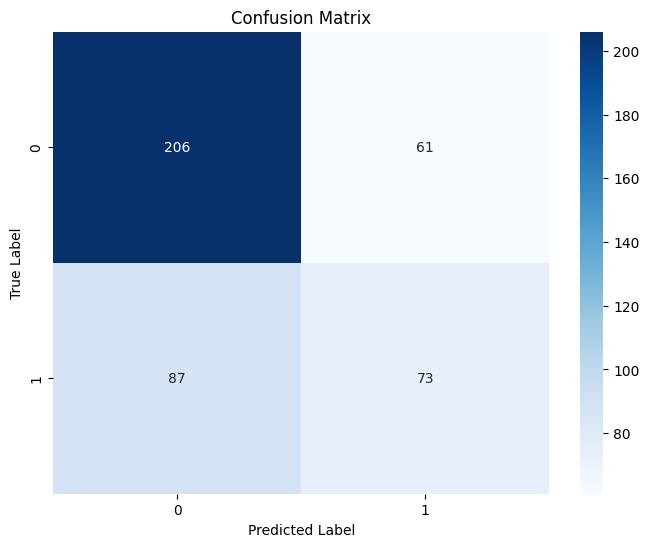

Accuracy : 0.6534
Precision: 0.6438
Recall   : 0.6534
F1-Score : 0.6461
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 0.8536 | Validation Acc: 0.6195
Training complete in 13m 11s
Frozen BERT Layers: 0 to 3
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.72      0.73       267
           1       0.55      0.57      0.56       160

    accuracy                           0.67       427
   macro avg       0.65      0.65      0.65       427
weighted avg       0.67      0.67      0.67       427



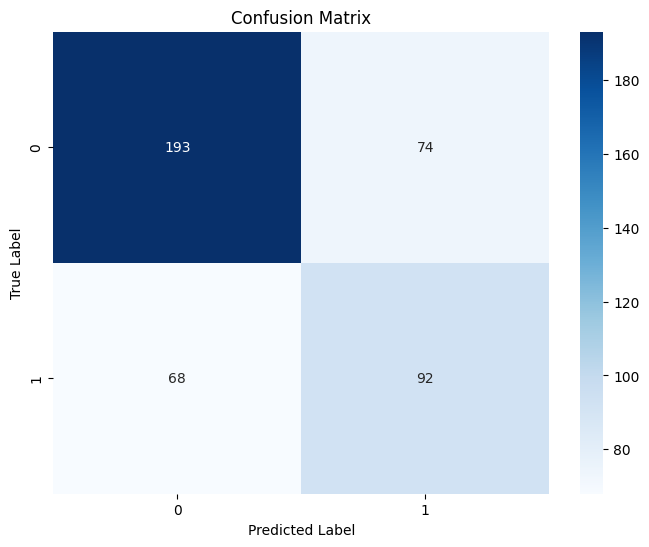

Accuracy : 0.6674
Precision: 0.6701
Recall   : 0.6674
F1-Score : 0.6686
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.1889 | Validation Acc: 0.6148
Training complete in 15m 57s
Frozen BERT Layers: 0 to 3
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       267
           1       0.56      0.53      0.55       160

    accuracy                           0.67       427
   macro avg       0.65      0.64      0.64       427
weighted avg       0.67      0.67      0.67       427



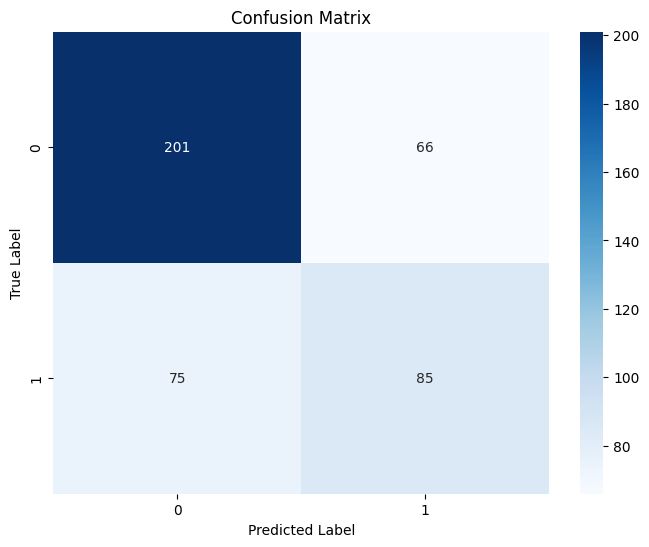

Accuracy : 0.6698
Precision: 0.6663
Recall   : 0.6698
F1-Score : 0.6677


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6112 | Validation Acc: 0.6566
----------
Epoch 2/6 | Validation Loss: 0.6329 | Validation Acc: 0.6636
----------
Epoch 3/6 | Validation Loss: 0.7023 | Validation Acc: 0.6497
Training complete in 7m 43s
Frozen BERT Layers: 0 to 3
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.70      0.71       267
           1       0.53      0.56      0.55       160

    accuracy                           0.65       427
   macro avg       0.63      0.63      0.63       427
weighted avg       0.65      0.65      0.65       427



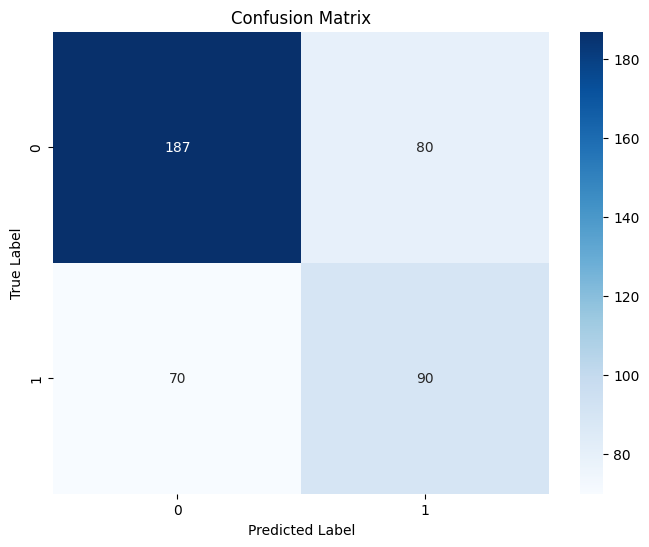

Accuracy : 0.6487
Precision: 0.6534
Recall   : 0.6487
F1-Score : 0.6507
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.8903 | Validation Acc: 0.5476
Training complete in 10m 27s
Frozen BERT Layers: 0 to 3
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.46      0.58       267
           1       0.47      0.79      0.59       160

    accuracy                           0.59       427
   macro avg       0.63      0.63      0.59       427
weighted avg       0.67      0.59      0.58       427



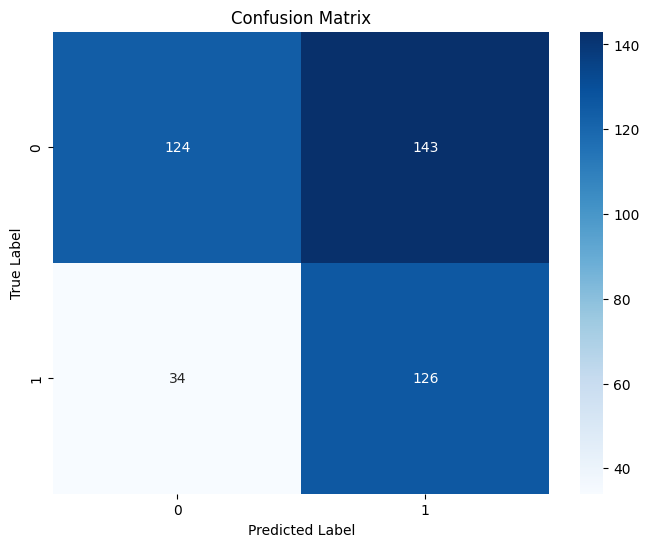

Accuracy : 0.5855
Precision: 0.6662
Recall   : 0.5855
F1-Score : 0.5850
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.0999 | Validation Acc: 0.6079
Training complete in 13m 11s
Frozen BERT Layers: 0 to 3
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.62      0.67       267
           1       0.49      0.62      0.55       160

    accuracy                           0.62       427
   macro avg       0.61      0.62      0.61       427
weighted avg       0.64      0.62      0.62       427



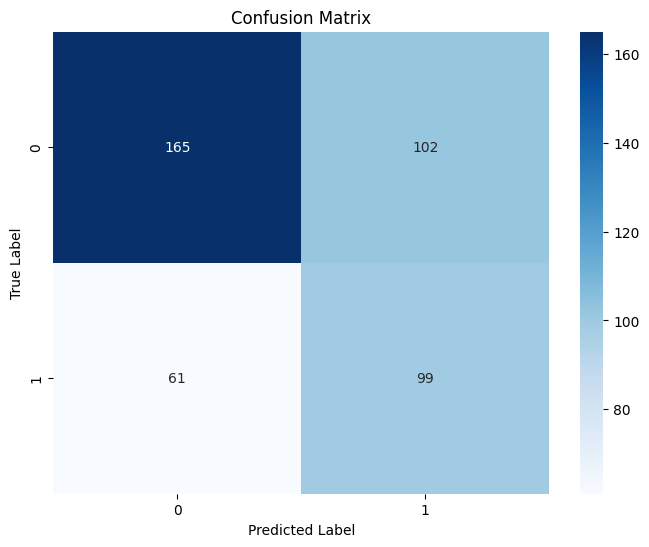

Accuracy : 0.6183
Precision: 0.6411
Recall   : 0.6183
F1-Score : 0.6241
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.0708 | Validation Acc: 0.6520
Training complete in 15m 55s
Frozen BERT Layers: 0 to 3
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       267
           1       0.51      0.49      0.50       160

    accuracy                           0.63       427
   macro avg       0.60      0.60      0.60       427
weighted avg       0.63      0.63      0.63       427



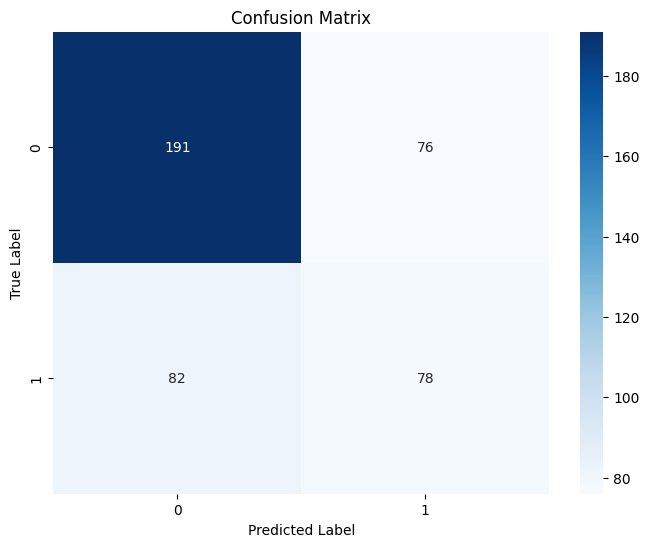

Accuracy : 0.6300
Precision: 0.6273
Recall   : 0.6300
F1-Score : 0.6285


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6140 | Validation Acc: 0.6566
----------
Epoch 2/6 | Validation Loss: 0.6279 | Validation Acc: 0.6450
----------
Epoch 3/6 | Validation Loss: 0.6523 | Validation Acc: 0.6543
Training complete in 7m 30s
Frozen BERT Layers: 0 to 5
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       267
           1       0.51      0.53      0.52       160

    accuracy                           0.63       427
   macro avg       0.61      0.61      0.61       427
weighted avg       0.63      0.63      0.63       427



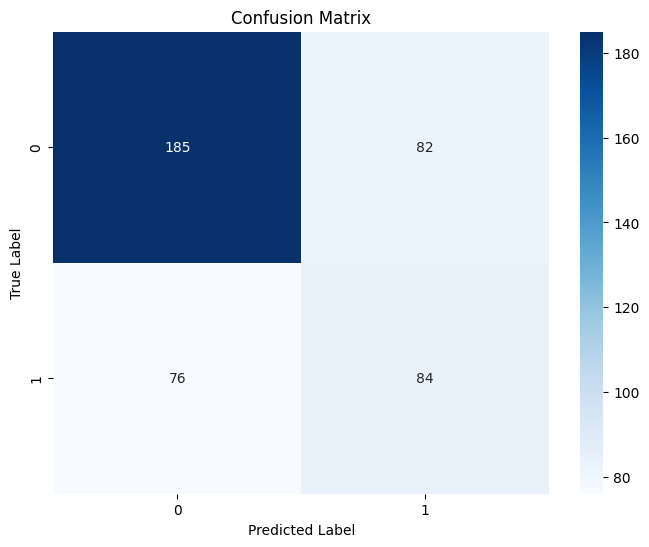

Accuracy : 0.6300
Precision: 0.6328
Recall   : 0.6300
F1-Score : 0.6313
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.7174 | Validation Acc: 0.6404
Training complete in 10m 9s
Frozen BERT Layers: 0 to 5
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       267
           1       0.54      0.58      0.56       160

    accuracy                           0.66       427
   macro avg       0.64      0.64      0.64       427
weighted avg       0.66      0.66      0.66       427



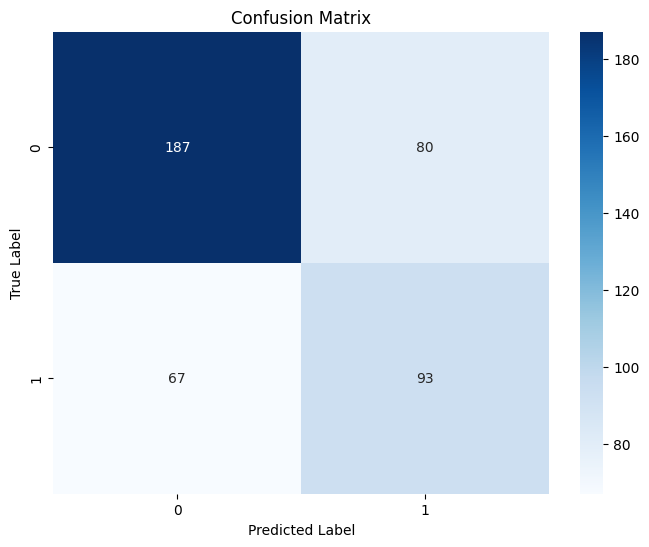

Accuracy : 0.6557
Precision: 0.6618
Recall   : 0.6557
F1-Score : 0.6582
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 0.8112 | Validation Acc: 0.6079
Training complete in 12m 48s
Frozen BERT Layers: 0 to 5
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.63      0.68       267
           1       0.50      0.61      0.55       160

    accuracy                           0.62       427
   macro avg       0.61      0.62      0.61       427
weighted avg       0.64      0.62      0.63       427



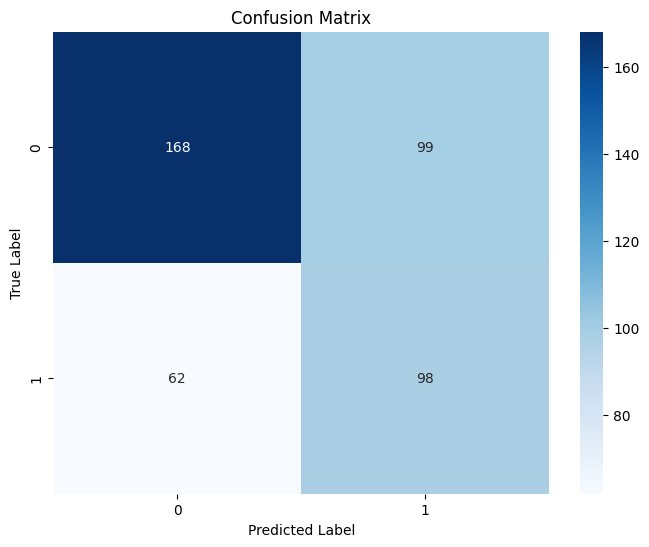

Accuracy : 0.6230
Precision: 0.6431
Recall   : 0.6230
F1-Score : 0.6285
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 0.9922 | Validation Acc: 0.6265
Training complete in 15m 29s
Frozen BERT Layers: 0 to 5
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       267
           1       0.47      0.44      0.45       160

    accuracy                           0.60       427
   macro avg       0.57      0.57      0.57       427
weighted avg       0.60      0.60      0.60       427



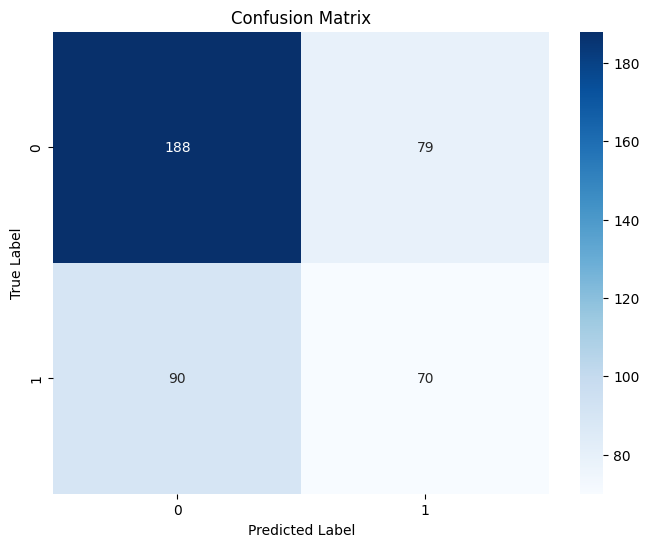

Accuracy : 0.6042
Precision: 0.5989
Recall   : 0.6042
F1-Score : 0.6012


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 0.6499 | Validation Acc: 0.6566
----------
Epoch 2/6 | Validation Loss: 0.6405 | Validation Acc: 0.6566
----------
Epoch 3/6 | Validation Loss: 0.6297 | Validation Acc: 0.6334
Training complete in 7m 28s
Frozen BERT Layers: 0 to 5
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.68      0.70       267
           1       0.51      0.54      0.52       160

    accuracy                           0.63       427
   macro avg       0.61      0.61      0.61       427
weighted avg       0.64      0.63      0.63       427



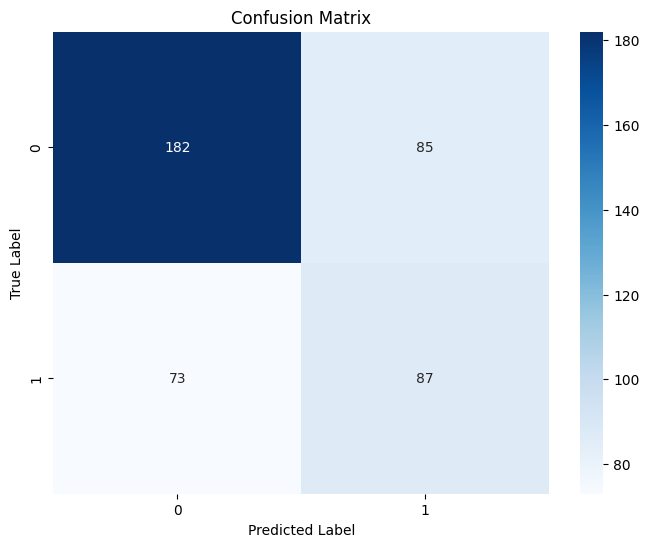

Accuracy : 0.6300
Precision: 0.6358
Recall   : 0.6300
F1-Score : 0.6324
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 0.6534 | Validation Acc: 0.6381
Training complete in 10m 5s
Frozen BERT Layers: 0 to 5
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.69      0.69       267
           1       0.49      0.51      0.50       160

    accuracy                           0.62       427
   macro avg       0.60      0.60      0.60       427
weighted avg       0.62      0.62      0.62       427



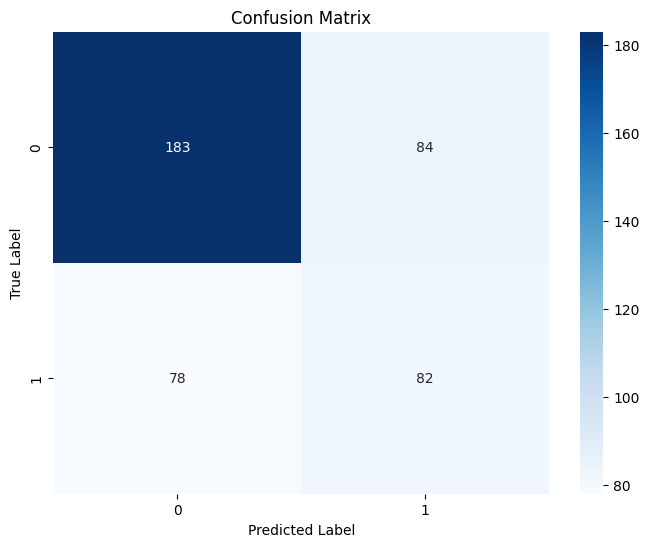

Accuracy : 0.6206
Precision: 0.6235
Recall   : 0.6206
F1-Score : 0.6219
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 0.6722 | Validation Acc: 0.6473
Training complete in 12m 41s
Frozen BERT Layers: 0 to 5
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       267
           1       0.54      0.39      0.45       160

    accuracy                           0.65       427
   macro avg       0.61      0.59      0.60       427
weighted avg       0.63      0.65      0.63       427



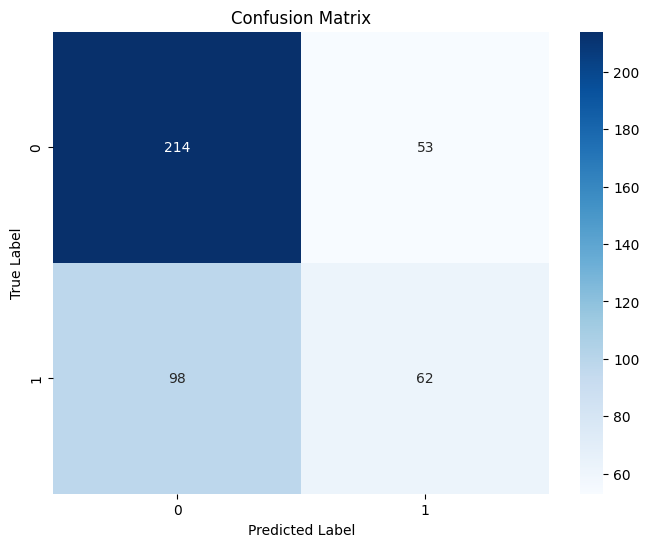

Accuracy : 0.6464
Precision: 0.6309
Recall   : 0.6464
F1-Score : 0.6312
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 0.7360 | Validation Acc: 0.6775
Training complete in 15m 21s
Frozen BERT Layers: 0 to 5
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.86      0.75       267
           1       0.55      0.29      0.38       160

    accuracy                           0.65       427
   macro avg       0.61      0.57      0.57       427
weighted avg       0.63      0.65      0.61       427



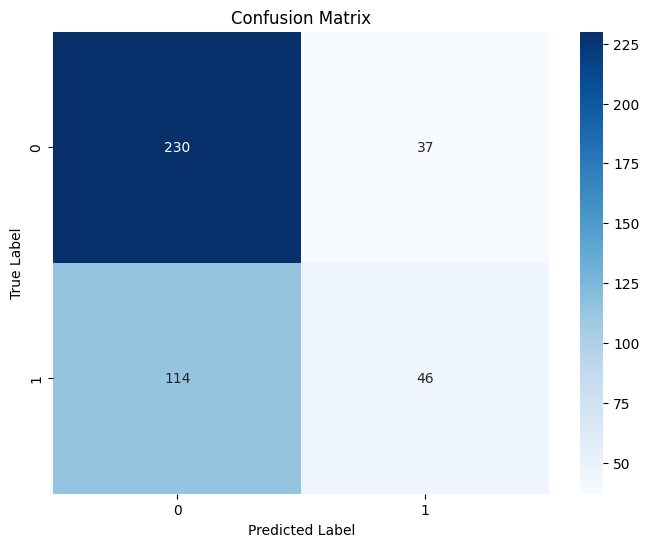

Accuracy : 0.6464
Precision: 0.6257
Recall   : 0.6464
F1-Score : 0.6126


In [26]:
Result(2)

/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.7491 | Validation Acc: 0.1972
----------
Epoch 2/6 | Validation Loss: 1.7267 | Validation Acc: 0.2204
----------
Epoch 3/6 | Validation Loss: 1.7221 | Validation Acc: 0.2343
Training complete in 8m 9s
Frozen BERT Layers: 0 to 1
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.27      0.28      0.27        86
           2       0.22      0.14      0.17        91
           3       0.23      0.75      0.35        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.23       427
   macro avg       0.12      0.20      0.13       427
weighted avg       0.15      0.23      0.16       427



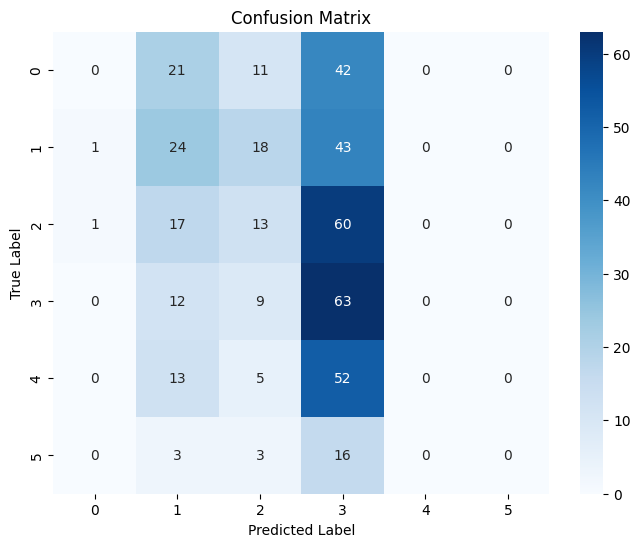

Accuracy : 0.2342
Precision: 0.1456
Recall   : 0.2342
F1-Score : 0.1607
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7751 | Validation Acc: 0.2320
Training complete in 11m 1s
Frozen BERT Layers: 0 to 1
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.30      0.60      0.40        86
           2       0.28      0.24      0.26        91
           3       0.25      0.51      0.34        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.14      0.23      0.17       427
weighted avg       0.17      0.27      0.20       427



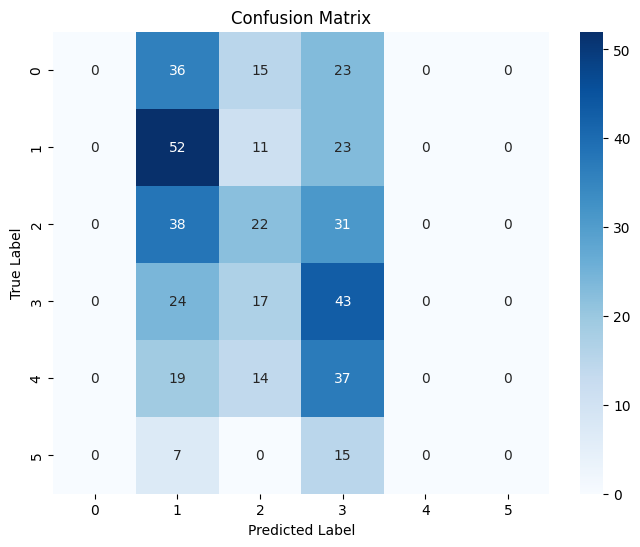

Accuracy : 0.2740
Precision: 0.1680
Recall   : 0.2740
F1-Score : 0.2012
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.8338 | Validation Acc: 0.2251
Training complete in 13m 53s
Frozen BERT Layers: 0 to 1
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.49      0.31        74
           1       0.27      0.15      0.19        86
           2       0.21      0.21      0.21        91
           3       0.26      0.42      0.32        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.24       427
   macro avg       0.16      0.21      0.17       427
weighted avg       0.19      0.24      0.20       427



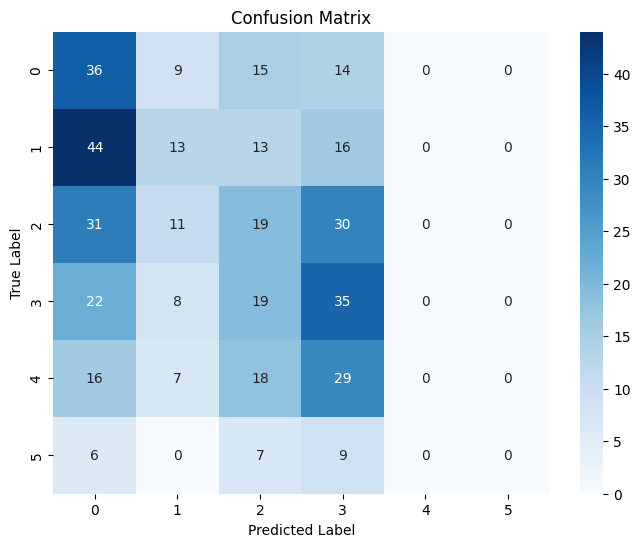

Accuracy : 0.2412
Precision: 0.1911
Recall   : 0.2412
F1-Score : 0.2015
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.9994 | Validation Acc: 0.2251
Training complete in 16m 44s
Frozen BERT Layers: 0 to 1
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.25      0.52      0.34        86
           2       0.15      0.09      0.11        91
           3       0.28      0.39      0.32        84
           4       0.20      0.21      0.21        70
           5       0.00      0.00      0.00        22

    accuracy                           0.24       427
   macro avg       0.15      0.20      0.16       427
weighted avg       0.17      0.24      0.19       427



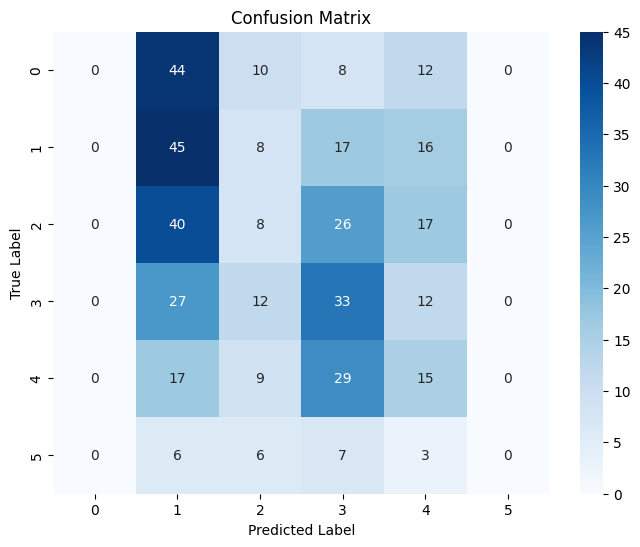

Accuracy : 0.2365
Precision: 0.1697
Recall   : 0.2365
F1-Score : 0.1896


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.8208 | Validation Acc: 0.1903
----------
Epoch 2/6 | Validation Loss: 1.7519 | Validation Acc: 0.1671
----------
Epoch 3/6 | Validation Loss: 1.7656 | Validation Acc: 0.2111
Training complete in 8m 10s
Frozen BERT Layers: 0 to 1
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.25      0.62      0.36        86
           2       0.22      0.54      0.32        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.24       427
   macro avg       0.08      0.19      0.11       427
weighted avg       0.10      0.24      0.14       427



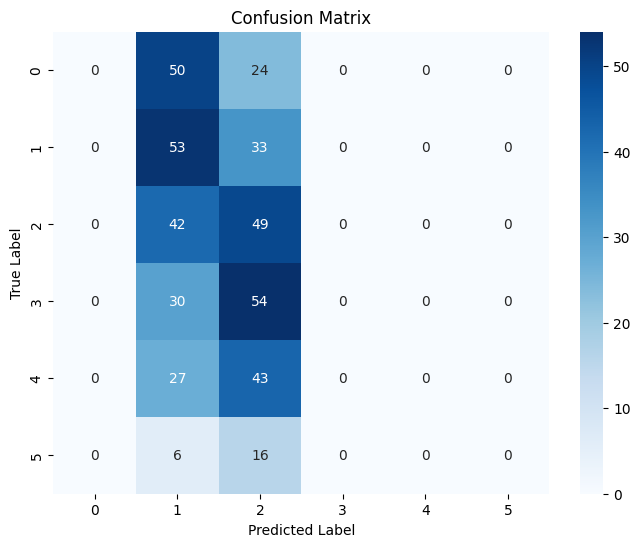

Accuracy : 0.2389
Precision: 0.0990
Recall   : 0.2389
F1-Score : 0.1400
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7422 | Validation Acc: 0.2181
Training complete in 11m 2s
Frozen BERT Layers: 0 to 1
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.20      0.10      0.14        86
           2       0.22      0.46      0.30        91
           3       0.25      0.56      0.34        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.23       427
   macro avg       0.11      0.19      0.13       427
weighted avg       0.14      0.23      0.16       427



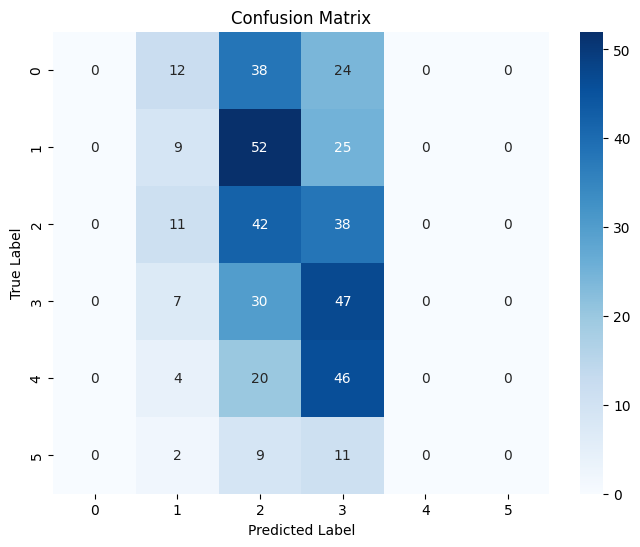

Accuracy : 0.2295
Precision: 0.1356
Recall   : 0.2295
F1-Score : 0.1584
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.9351 | Validation Acc: 0.2181
Training complete in 13m 54s
Frozen BERT Layers: 0 to 1
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.24      0.63      0.35        86
           2       0.19      0.36      0.25        91
           3       1.00      0.01      0.02        84
           4       0.30      0.13      0.18        70
           5       0.00      0.00      0.00        22

    accuracy                           0.23       427
   macro avg       0.29      0.19      0.13       427
weighted avg       0.34      0.23      0.16       427



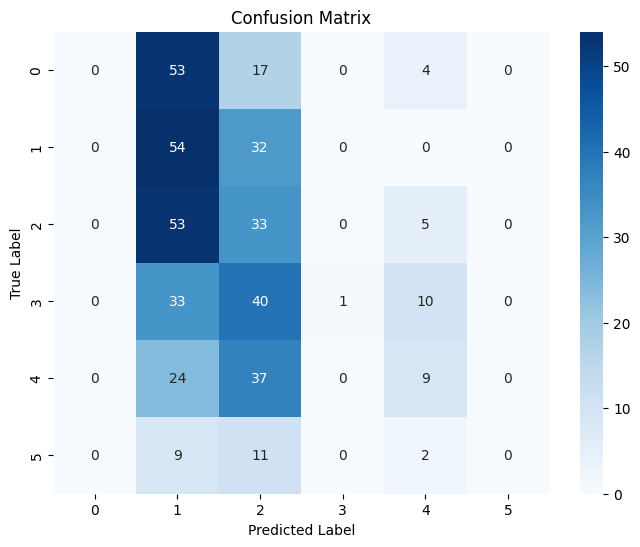

Accuracy : 0.2272
Precision: 0.3354
Recall   : 0.2272
F1-Score : 0.1577
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 2.2425 | Validation Acc: 0.2042
Training complete in 16m 48s
Frozen BERT Layers: 0 to 1
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.27      0.55      0.36        86
           2       0.26      0.52      0.35        91
           3       0.60      0.04      0.07        84
           4       0.25      0.24      0.25        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.23      0.22      0.17       427
weighted avg       0.27      0.27      0.20       427



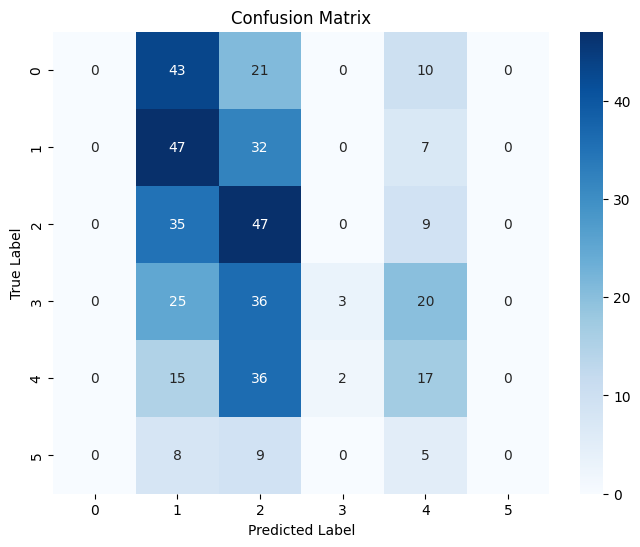

Accuracy : 0.2670
Precision: 0.2691
Recall   : 0.2670
F1-Score : 0.2004


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.7473 | Validation Acc: 0.2042
----------
Epoch 2/6 | Validation Loss: 1.7558 | Validation Acc: 0.1949
----------
Epoch 3/6 | Validation Loss: 1.7571 | Validation Acc: 0.2065
Training complete in 7m 42s
Frozen BERT Layers: 0 to 3
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.33      0.10      0.16        86
           2       0.00      0.00      0.00        91
           3       0.19      0.92      0.32        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.20       427
   macro avg       0.09      0.17      0.08       427
weighted avg       0.11      0.20      0.09       427



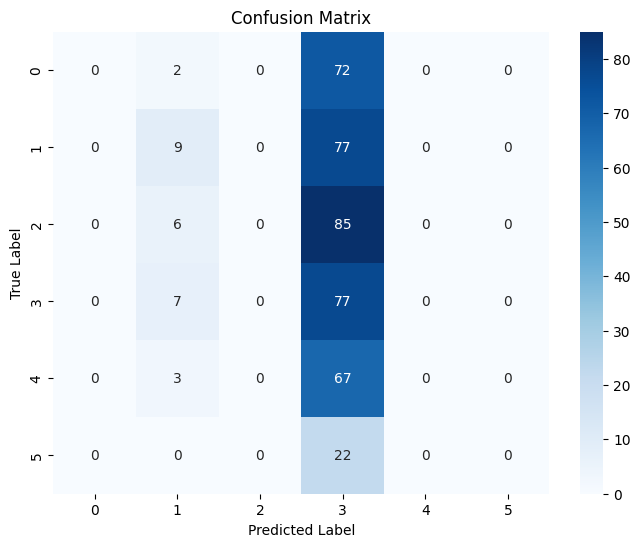

Accuracy : 0.2014
Precision: 0.1050
Recall   : 0.2014
F1-Score : 0.0947
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7558 | Validation Acc: 0.2042
Training complete in 10m 25s
Frozen BERT Layers: 0 to 3
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.00      0.00      0.00        86
           2       0.21      1.00      0.35        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.21       427
   macro avg       0.04      0.17      0.06       427
weighted avg       0.05      0.21      0.07       427



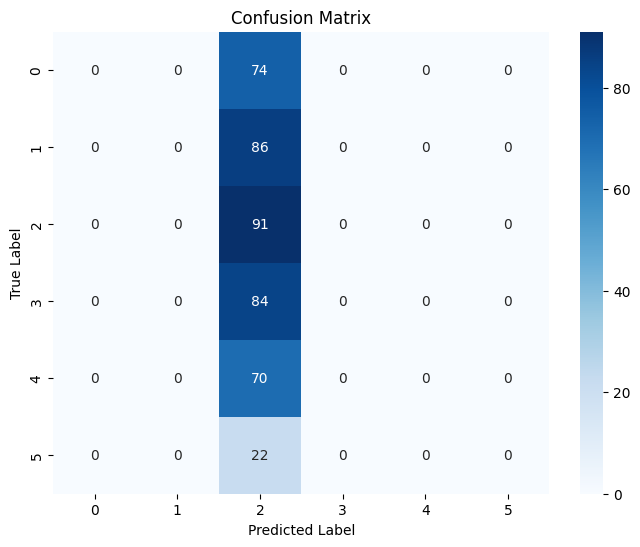

Accuracy : 0.2131
Precision: 0.0454
Recall   : 0.2131
F1-Score : 0.0749
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.7557 | Validation Acc: 0.2065
Training complete in 13m 11s
Frozen BERT Layers: 0 to 3
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.11      0.03      0.05        86
           2       0.00      0.00      0.00        91
           3       0.20      0.93      0.32        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.19       427
   macro avg       0.05      0.16      0.06       427
weighted avg       0.06      0.19      0.07       427



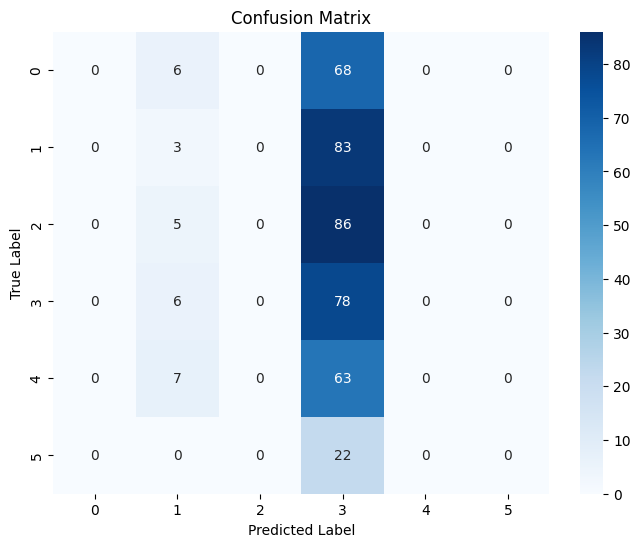

Accuracy : 0.1897
Precision: 0.0607
Recall   : 0.1897
F1-Score : 0.0741
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.7633 | Validation Acc: 0.2065
Training complete in 15m 58s
Frozen BERT Layers: 0 to 3
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.22      0.07      0.11        86
           2       0.21      0.93      0.35        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.21       427
   macro avg       0.07      0.17      0.08       427
weighted avg       0.09      0.21      0.10       427



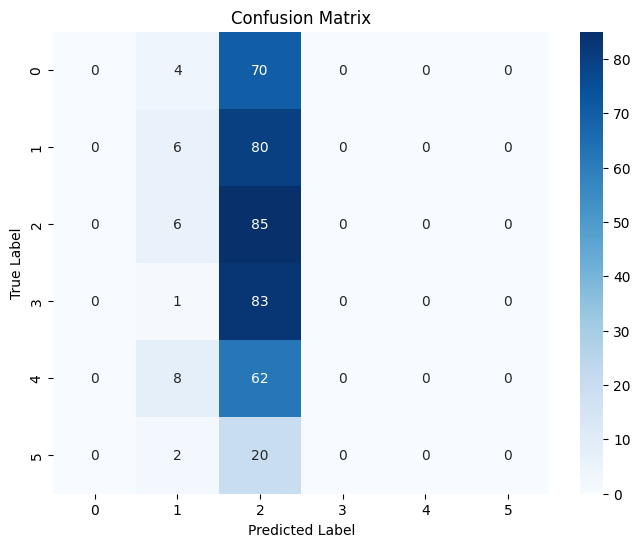

Accuracy : 0.2131
Precision: 0.0900
Recall   : 0.2131
F1-Score : 0.0952


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.7547 | Validation Acc: 0.2042
----------
Epoch 2/6 | Validation Loss: 1.7624 | Validation Acc: 0.1949
----------
Epoch 3/6 | Validation Loss: 1.7475 | Validation Acc: 0.1903
Training complete in 7m 42s
Frozen BERT Layers: 0 to 3
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.28      0.69      0.40        86
           2       0.24      0.57      0.34        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.26       427
   macro avg       0.09      0.21      0.12       427
weighted avg       0.11      0.26      0.15       427



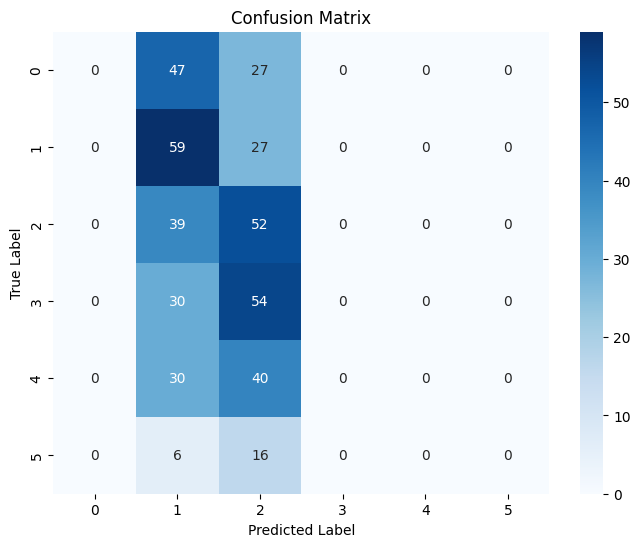

Accuracy : 0.2600
Precision: 0.1076
Recall   : 0.2600
F1-Score : 0.1522
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7516 | Validation Acc: 0.2436
Training complete in 10m 26s
Frozen BERT Layers: 0 to 3
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.24      0.14      0.17        74
           1       0.29      0.41      0.34        86
           2       0.25      0.04      0.07        91
           3       0.23      0.68      0.34        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.25       427
   macro avg       0.17      0.21      0.16       427
weighted avg       0.20      0.25      0.18       427



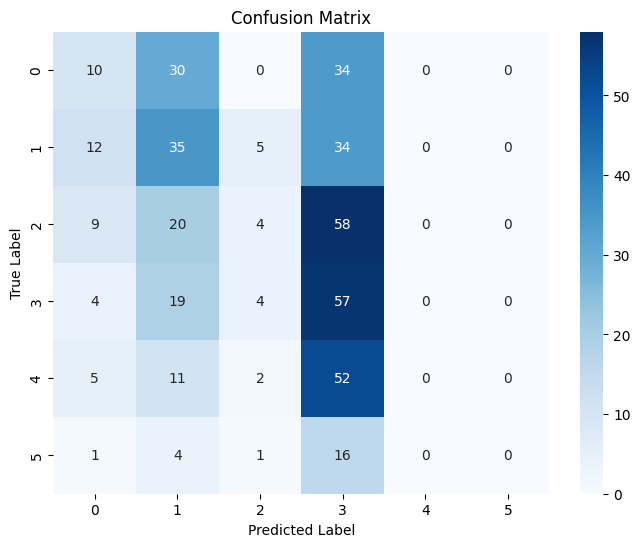

Accuracy : 0.2482
Precision: 0.1995
Recall   : 0.2482
F1-Score : 0.1818
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.7299 | Validation Acc: 0.2390
Training complete in 13m 10s
Frozen BERT Layers: 0 to 3
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.30      0.53      0.38        86
           2       0.22      0.26      0.24        91
           3       0.30      0.58      0.39        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.28       427
   macro avg       0.14      0.23      0.17       427
weighted avg       0.17      0.28      0.21       427



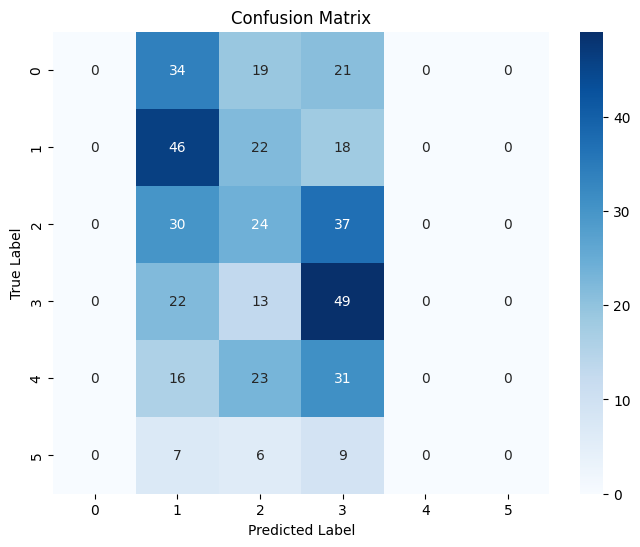

Accuracy : 0.2787
Precision: 0.1660
Recall   : 0.2787
F1-Score : 0.2060
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.8042 | Validation Acc: 0.2483
Training complete in 15m 56s
Frozen BERT Layers: 0 to 3
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.29      0.36      0.32        74
           1       0.00      0.00      0.00        86
           2       0.21      0.51      0.30        91
           3       0.36      0.49      0.41        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.14      0.23      0.17       427
weighted avg       0.17      0.27      0.20       427



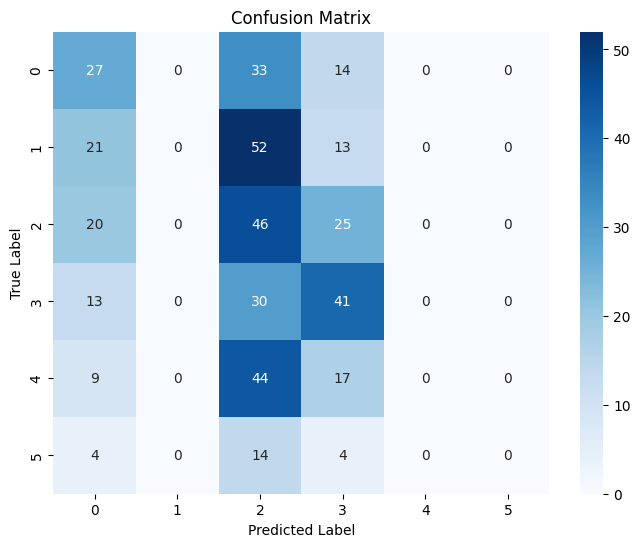

Accuracy : 0.2670
Precision: 0.1653
Recall   : 0.2670
F1-Score : 0.2004


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.7607 | Validation Acc: 0.2065
----------
Epoch 2/6 | Validation Loss: 1.7322 | Validation Acc: 0.2413
----------
Epoch 3/6 | Validation Loss: 1.7501 | Validation Acc: 0.1833
Training complete in 7m 29s
Frozen BERT Layers: 0 to 5
Epoch: 3
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.89      0.32        74
           1       0.00      0.00      0.00        86
           2       0.00      0.00      0.00        91
           3       0.41      0.45      0.43        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.24       427
   macro avg       0.10      0.22      0.13       427
weighted avg       0.11      0.24      0.14       427



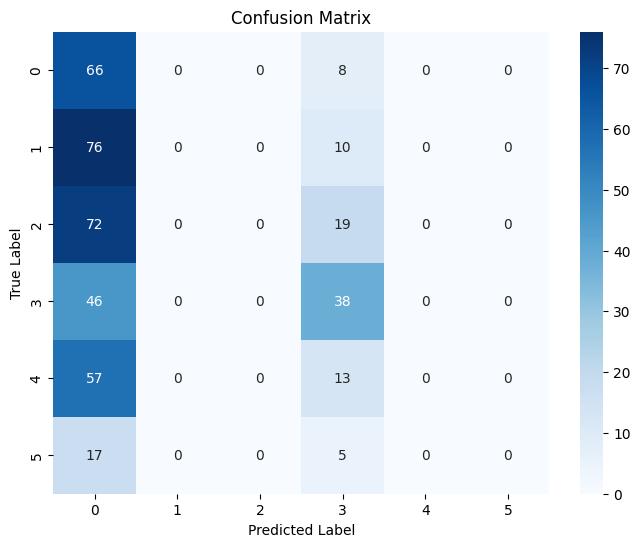

Accuracy : 0.2436
Precision: 0.1146
Recall   : 0.2436
F1-Score : 0.1405
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7451 | Validation Acc: 0.2320
Training complete in 10m 8s
Frozen BERT Layers: 0 to 5
Epoch: 4
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.26      0.80      0.39        86
           2       1.00      0.01      0.02        91
           3       0.29      0.55      0.38        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.26      0.23      0.13       427
weighted avg       0.32      0.27      0.16       427



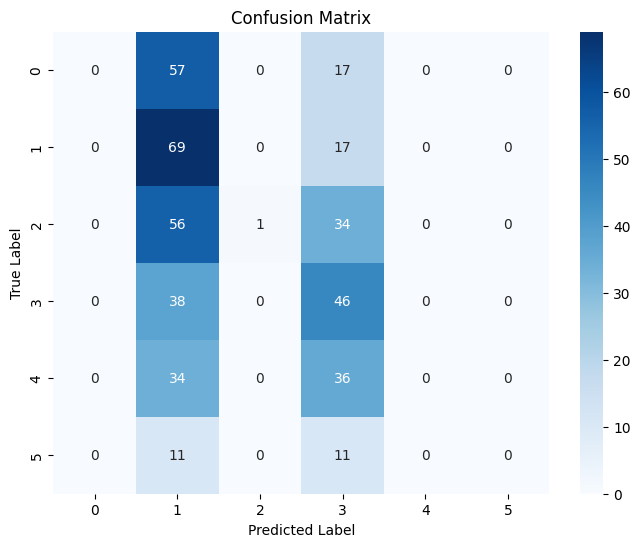

Accuracy : 0.2717
Precision: 0.3218
Recall   : 0.2717
F1-Score : 0.1577
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.8428 | Validation Acc: 0.2506
Training complete in 12m 49s
Frozen BERT Layers: 0 to 5
Epoch: 5
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.31      0.42      0.35        86
           2       0.20      0.44      0.28        91
           3       0.35      0.46      0.40        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.14      0.22      0.17       427
weighted avg       0.17      0.27      0.21       427



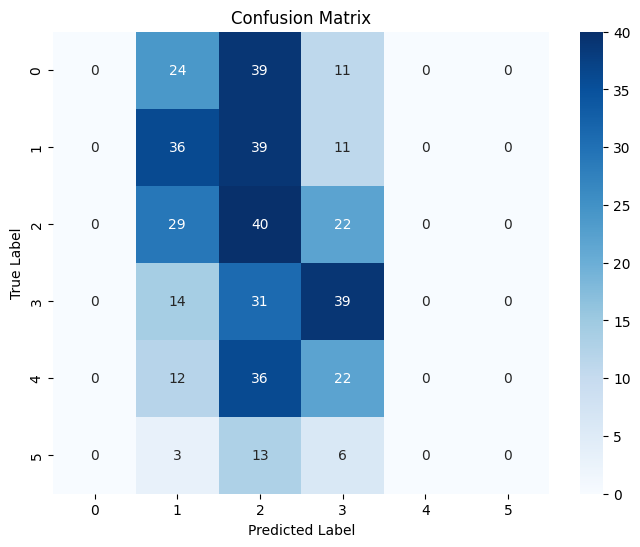

Accuracy : 0.2693
Precision: 0.1736
Recall   : 0.2693
F1-Score : 0.2088
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.8687 | Validation Acc: 0.2343
Training complete in 15m 29s
Frozen BERT Layers: 0 to 5
Epoch: 6
Learning Rate: 2e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.30      0.62      0.40        86
           2       0.20      0.31      0.24        91
           3       0.40      0.35      0.37        84
           4       0.19      0.10      0.13        70
           5       0.00      0.00      0.00        22

    accuracy                           0.27       427
   macro avg       0.18      0.23      0.19       427
weighted avg       0.21      0.27      0.23       427



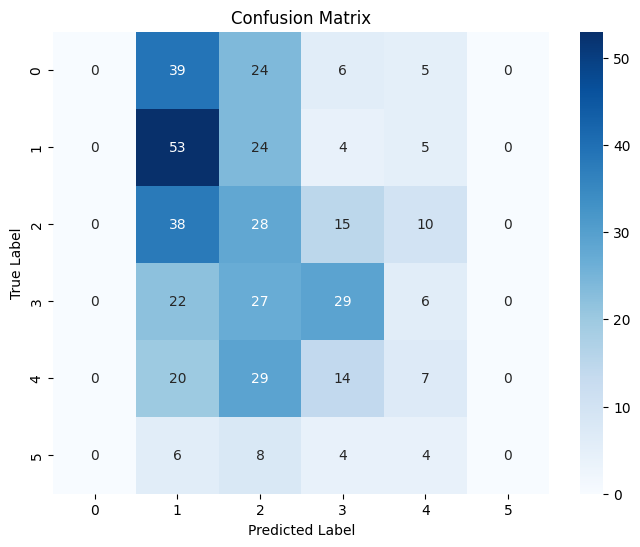

Accuracy : 0.2740
Precision: 0.2128
Recall   : 0.2740
F1-Score : 0.2271


/tmp/ipykernel_19/61087722.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


----------
Epoch 1/6 | Validation Loss: 1.7570 | Validation Acc: 0.2042
----------
Epoch 2/6 | Validation Loss: 1.7557 | Validation Acc: 0.1926
----------
Epoch 3/6 | Validation Loss: 1.7605 | Validation Acc: 0.2042
Training complete in 7m 28s
Frozen BERT Layers: 0 to 5
Epoch: 3
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.00      0.00      0.00        86
           2       0.21      1.00      0.35        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.21       427
   macro avg       0.04      0.17      0.06       427
weighted avg       0.05      0.21      0.07       427



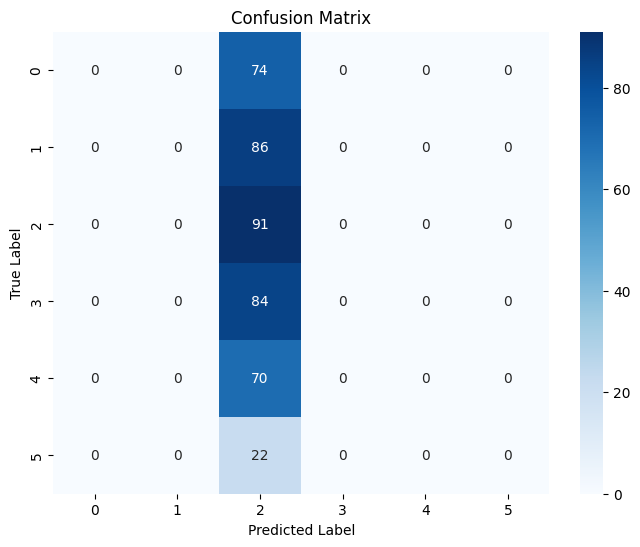

Accuracy : 0.2131
Precision: 0.0454
Recall   : 0.2131
F1-Score : 0.0749
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/6 | Validation Loss: 1.7674 | Validation Acc: 0.1439
Training complete in 10m 7s
Frozen BERT Layers: 0 to 5
Epoch: 4
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.17      1.00      0.30        74
           1       0.00      0.00      0.00        86
           2       0.00      0.00      0.00        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.17       427
   macro avg       0.03      0.17      0.05       427
weighted avg       0.03      0.17      0.05       427



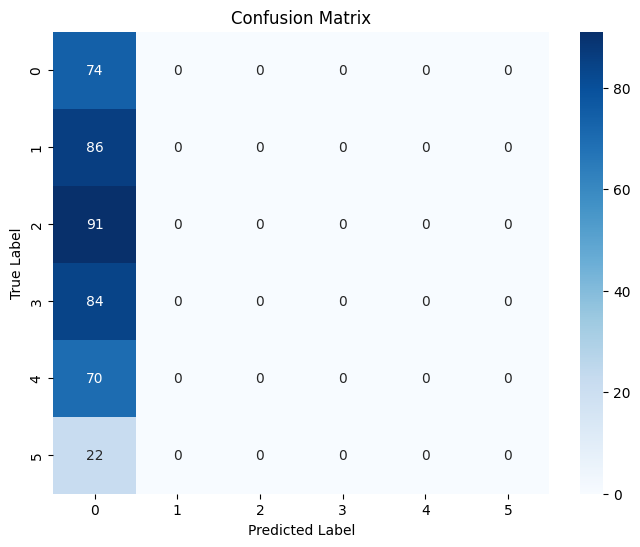

Accuracy : 0.1733
Precision: 0.0300
Recall   : 0.1733
F1-Score : 0.0512
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 5/6 | Validation Loss: 1.7549 | Validation Acc: 0.1926
Training complete in 12m 50s
Frozen BERT Layers: 0 to 5
Epoch: 5
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.00      0.00      0.00        86
           2       0.23      0.92      0.36        91
           3       0.26      0.17      0.20        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.23       427
   macro avg       0.08      0.18      0.09       427
weighted avg       0.10      0.23      0.12       427



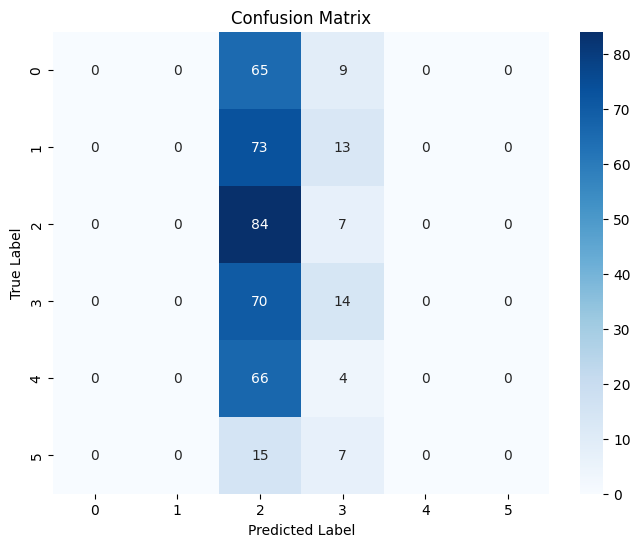

Accuracy : 0.2295
Precision: 0.0990
Recall   : 0.2295
F1-Score : 0.1171
----------


/tmp/ipykernel_19/61087722.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 6/6 | Validation Loss: 1.7522 | Validation Acc: 0.2042
Training complete in 15m 30s
Frozen BERT Layers: 0 to 5
Epoch: 6
Learning Rate: 3e-05


/tmp/ipykernel_19/2731253061.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        74
           1       0.00      0.00      0.00        86
           2       0.21      1.00      0.35        91
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00        70
           5       0.00      0.00      0.00        22

    accuracy                           0.21       427
   macro avg       0.04      0.17      0.06       427
weighted avg       0.05      0.21      0.07       427



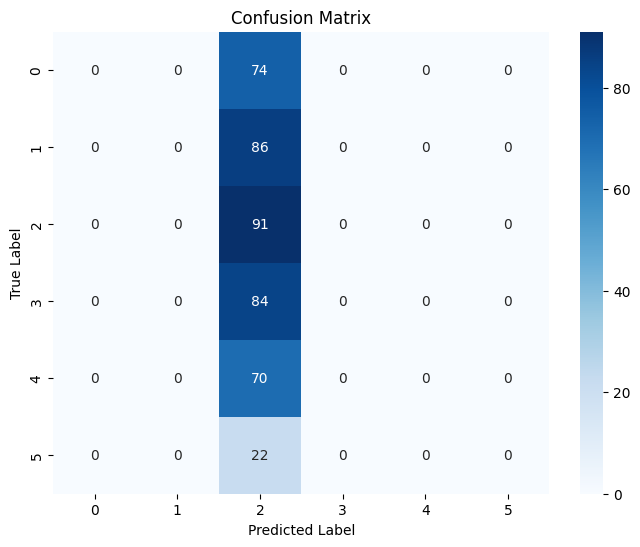

Accuracy : 0.2131
Precision: 0.0454
Recall   : 0.2131
F1-Score : 0.0749


In [27]:
Result(6)